In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch.nn as nn

from neuralhydrology.utils.config import Config

import matplotlib.pyplot as plt
import torch
from neuralhydrology.nh_run import start_run, eval_run
import pickle

### Do a training run  

In [3]:
start_run(config_file=Path("2basin-test-oracle.yml"), gpu=-1)

2026-01-29 13:41:26,430: Logging to /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_2901_134126/output.log initialized.
2026-01-29 13:41:26,431: ### Folder structure created at /Users/ziyu/Library/CloudStorage/OneDrive-ColoradoSchoolofMines/Documents/College/ResearchStuff/NextGen/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_2901_134126
2026-01-29 13:41:26,431: ### Run configurations for test_SHM
2026-01-29 13:41:26,431: experiment_name: test_SHM
2026-01-29 13:41:26,432: train_basin_file: 2_basin.txt
2026-01-29 13:41:26,432: validation_basin_file: 2_basin.txt
2026-01-29 13:41:26,432: test_basin_file: 2_basin.txt
2026-01-29 13:41:26,433: train_start_date: 2000-10-01 00:00:00
2026-01-29 13:41:26,433: train_end_date: 2014-09-30 00:00:00
2026-01-29 13:41:26,433: validation_start_date: 1990-10-01 00:00:00
2026-01-29 13:41:26,434: validation_end_date: 1999-09-30 00:00:00
2026-01-29

### Model Evaluation
Let's load up the model and see how it did.

In [3]:
run_dir = Path("runs/test_SHM_2901_134126") # oracle 02/26/26
from neuralhydrology.evaluation.tester import RegressionTester
tester = RegressionTester(run_dir=run_dir, cfg=Config(run_dir / "config.yml"))
tester.evaluate(save_all_output=True)

# Evaluation:   0%|          | 0/2 [03:12<?, ?it/s]


TypeError: The first input argument needs to be a sequence

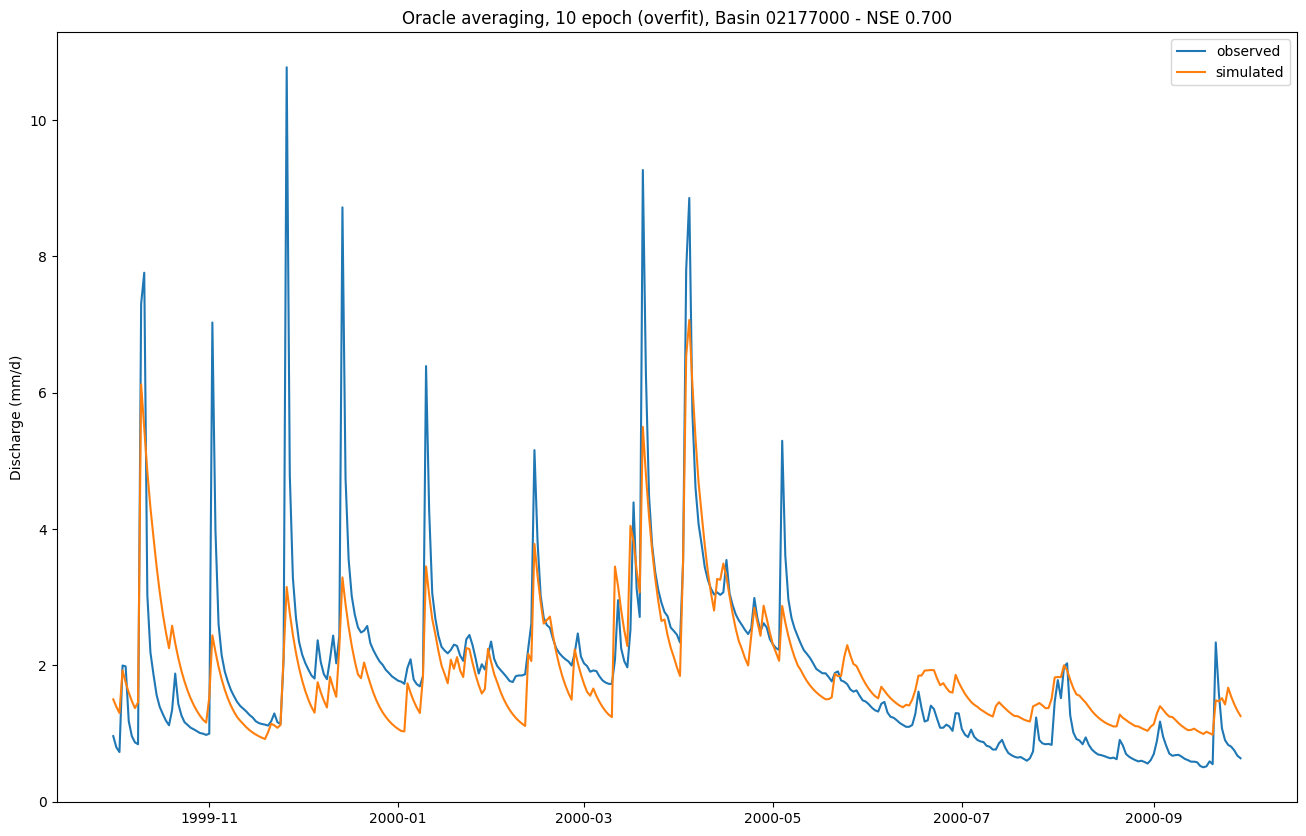

In [16]:
with open(run_dir / "test" / "model_epoch010" / "test_results.p", "rb") as fp:
    results = pickle.load(fp)
    
# Extract a data slice of observations and simulations
results_xr = results["02177000"]['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar data and the 1D array of time_step values
date_scalar = results_xr.coords['date'][0].values
time_step_values = results_xr.coords['time_step'].values

# Broadcast the scalar date across time_step and add the timedelta
datetime_values = date_scalar + pd.to_timedelta(time_step_values, unit='D')

# Add the datetime as a new coordinate to Result_xr
results_xr = results_xr.assign_coords(datetime=("time_step", datetime_values))

qobs = results_xr['QObs(mm/d)_obs']
qsim_oracle = results_xr['QObs(mm/d)_sim']

# extract observations and simulations
fig, ax = plt.subplots(figsize=(16,10))
ax.plot(qobs['datetime'], qobs[0], label='observed')
ax.plot(qsim_oracle['datetime'], qsim_oracle[0], label='simulated')
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Oracle averaging, 10 epoch (overfit), Basin 02177000 - NSE {results['02177000']['1D']['NSE']:.3f}")
ax.legend()

## Dynamic Parameters
Now let's test the same model and same training data, but with dynamic parameters

In [5]:
start_run(config_file=Path("2basin-test-dynamic.yml"), gpu=-1)

2026-01-16 13:22:17,463: Logging to /Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_1601_132217/output.log initialized.
2026-01-16 13:22:17,464: ### Folder structure created at /Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_1601_132217
2026-01-16 13:22:17,464: ### Run configurations for test_SHM
2026-01-16 13:22:17,465: experiment_name: test_SHM
2026-01-16 13:22:17,465: train_basin_file: 2_basin.txt
2026-01-16 13:22:17,465: validation_basin_file: 2_basin.txt
2026-01-16 13:22:17,465: test_basin_file: 2_basin.txt
2026-01-16 13:22:17,466: train_start_date: 2000-10-01 00:00:00
2026-01-16 13:22:17,466: train_end_date: 2014-09-30 00:00:00
2026-01-16 13:22:17,466: validation_start_date: 1990-10-01 00:00:00
2026-01-16 13:22:17,467: validation_end_date: 1999-09-30 00:00:00
2026-01-16 13:22:17,467: test_start_date: 1999-10-01 00:00:00
2026-01-16 13:22:17,467: test_end_date: 2004-09-30

In [17]:
run_dir = Path("runs/test_SHM_1601_132217")
eval_run(run_dir=run_dir, period="test")

2026-01-16 14:42:19,594: Using the model weights from runs/test_SHM_1601_132217/model_epoch010.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:01<00:00,  1.04it/s]
2026-01-16 14:42:21,528: Stored metrics at runs/test_SHM_1601_132217/test/model_epoch010/test_metrics.csv
2026-01-16 14:42:21,531: Stored results at runs/test_SHM_1601_132217/test/model_epoch010/test_results.p


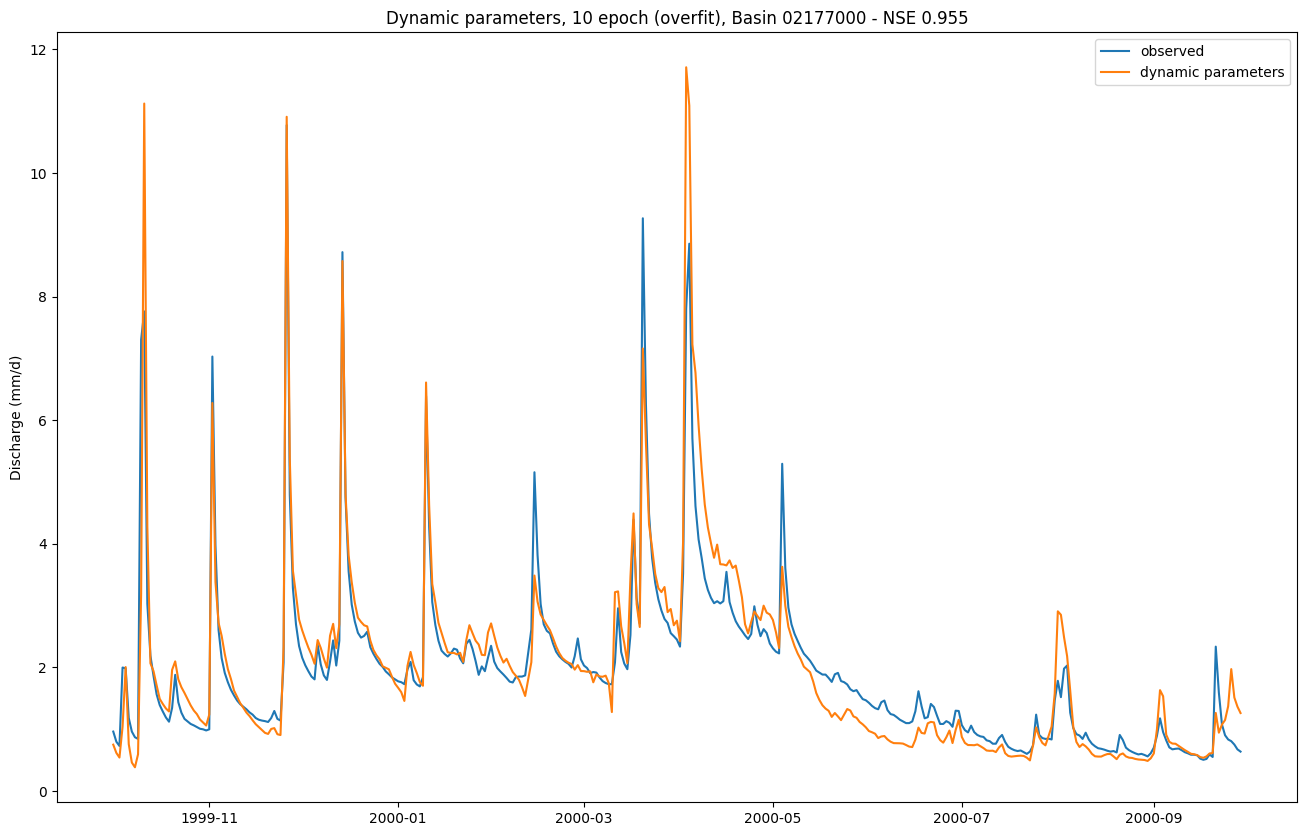

In [18]:
with open(run_dir / "test" / "model_epoch010" / "test_results.p", "rb") as fp:
    results = pickle.load(fp)
    
# Extract a data slice of observations and simulations
results_xr = results["02177000"]['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar data and the 1D array of time_step values
date_scalar = results_xr.coords['date'][0].values
time_step_values = results_xr.coords['time_step'].values

# Broadcast the scalar date across time_step and add the timedelta
datetime_values = date_scalar + pd.to_timedelta(time_step_values, unit='D')

# Add the datetime as a new coordinate to Result_xr
results_xr = results_xr.assign_coords(datetime=("time_step", datetime_values))

qobs = results_xr['QObs(mm/d)_obs']
qsim_dynamic = results_xr['QObs(mm/d)_sim']

# extract observations and simulations
fig, ax = plt.subplots(figsize=(16,10))
ax.plot(qobs['datetime'], qobs[0],label='observed')
ax.plot(qsim_dynamic['datetime'], qsim_dynamic[0],label='dynamic parameters')
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Dynamic parameters, 10 epoch (overfit), Basin 02177000 - NSE {results['02177000']['1D']['NSE']:.3f}")
ax.legend()

### Operational mode
Now test second parameter averaging scheme.

In [8]:
start_run(config_file=Path("2basin-test-operational.yml"), gpu=-1)

2026-01-16 13:25:48,250: Logging to /Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_1601_132548/output.log initialized.
2026-01-16 13:25:48,250: ### Folder structure created at /Users/danielmckenzie/Documents/Active_Research/Ziyu/neuralhydrology-dcfe/examples/08-SHM/runs/test_SHM_1601_132548
2026-01-16 13:25:48,250: ### Run configurations for test_SHM
2026-01-16 13:25:48,251: experiment_name: test_SHM
2026-01-16 13:25:48,251: train_basin_file: 2_basin.txt
2026-01-16 13:25:48,252: validation_basin_file: 2_basin.txt
2026-01-16 13:25:48,252: test_basin_file: 2_basin.txt
2026-01-16 13:25:48,253: train_start_date: 2000-10-01 00:00:00
2026-01-16 13:25:48,253: train_end_date: 2014-09-30 00:00:00
2026-01-16 13:25:48,254: validation_start_date: 1990-10-01 00:00:00
2026-01-16 13:25:48,254: validation_end_date: 1999-09-30 00:00:00
2026-01-16 13:25:48,254: test_start_date: 1999-10-01 00:00:00
2026-01-16 13:25:48,255: test_end_date: 2004-09-30

In [20]:
run_dir = Path("runs/test_SHM_1601_132548")
eval_run(run_dir=run_dir, period="test")

2026-01-16 14:44:03,349: Using the model weights from runs/test_SHM_1601_132548/model_epoch010.pt
Metrics for 1D are calculated over last 1 elements only. Ignoring 364 predictions per sequence.
# Evaluation: 100%|██████████| 2/2 [00:03<00:00,  1.74s/it]
2026-01-16 14:44:06,843: Stored metrics at runs/test_SHM_1601_132548/test/model_epoch010/test_metrics.csv
2026-01-16 14:44:06,847: Stored results at runs/test_SHM_1601_132548/test/model_epoch010/test_results.p


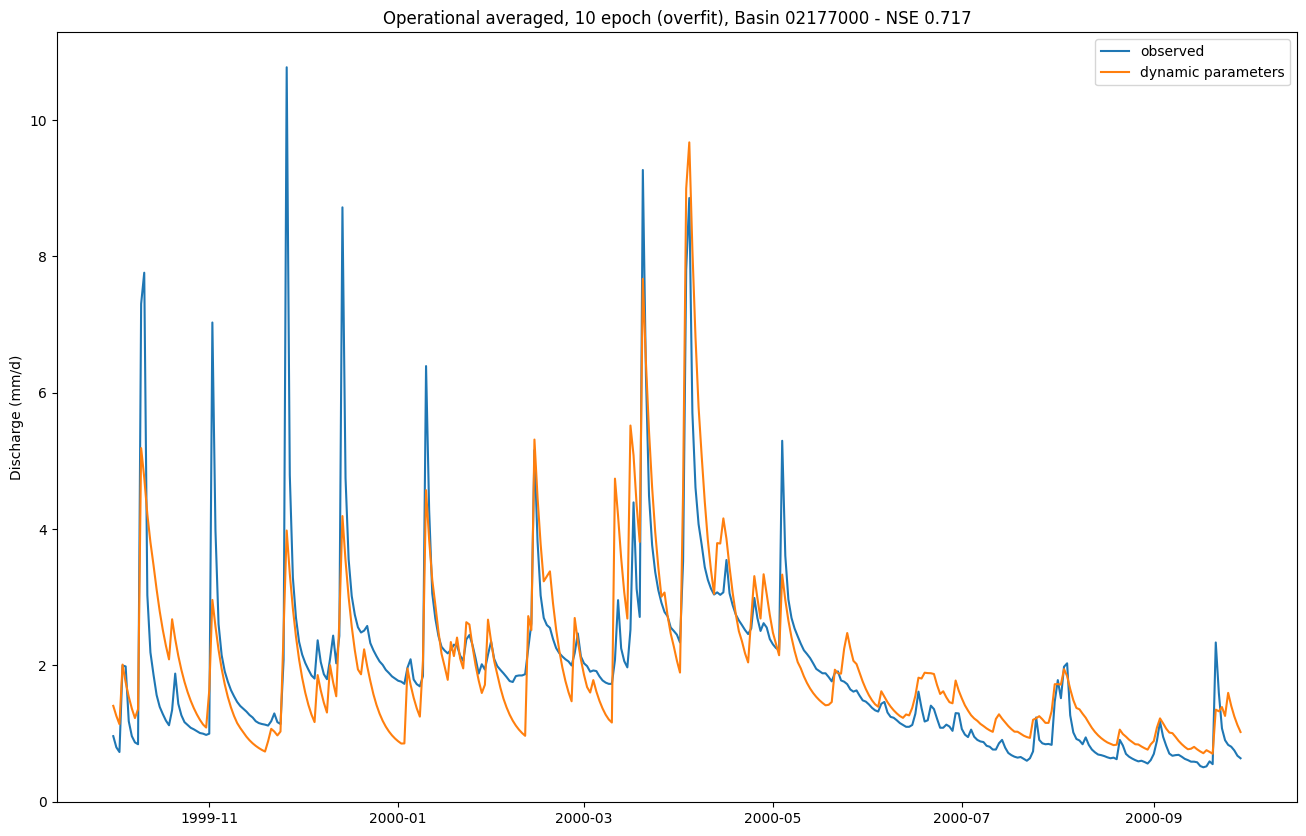

In [21]:
with open(run_dir / "test" / "model_epoch010" / "test_results.p", "rb") as fp:
    results = pickle.load(fp)
    
# Extract a data slice of observations and simulations
results_xr = results["02177000"]['1D']['xr'].sel(date=slice("10-1999", None))

# Get the scalar data and the 1D array of time_step values
date_scalar = results_xr.coords['date'][0].values
time_step_values = results_xr.coords['time_step'].values

# Broadcast the scalar date across time_step and add the timedelta
datetime_values = date_scalar + pd.to_timedelta(time_step_values, unit='D')

# Add the datetime as a new coordinate to Result_xr
results_xr = results_xr.assign_coords(datetime=("time_step", datetime_values))

qobs = results_xr['QObs(mm/d)_obs']
qsim_operational = results_xr['QObs(mm/d)_sim']

# extract observations and simulations
fig, ax = plt.subplots(figsize=(16,10))
ax.plot(qobs['datetime'], qobs[0],label='observed')
ax.plot(qsim_operational['datetime'], qsim_operational[0],label='dynamic parameters')
ax.set_ylabel("Discharge (mm/d)")
ax.set_title(f"Operational averaged, 10 epoch (overfit), Basin 02177000 - NSE {results['02177000']['1D']['NSE']:.3f}")
ax.legend()

### Comparing dynamic vs oracle averaged
Let's plot them all on the same axes.

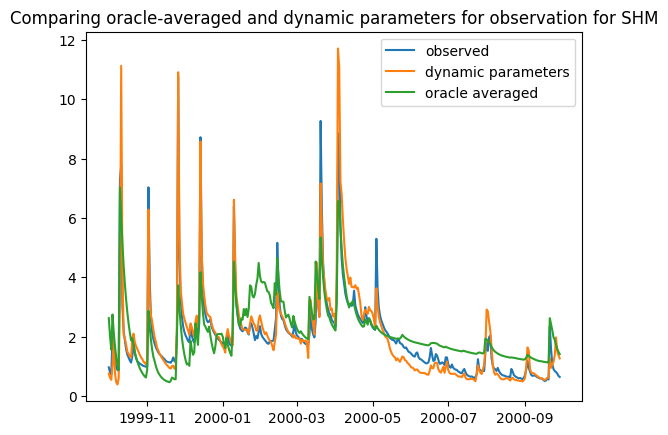

In [ ]:
# extract observations and simulations
plt.plot(qobs['datetime'], qobs[0],label='observed')
plt.plot(qsim_dynamic['datetime'], qsim_dynamic[0],label='dynamic parameters')
plt.plot(qsim_oracle['datetime'], qsim_oracle[0], label='oracle averaged')
plt.plot(qsim_operational['datetime'], qsim_operational[0], label='operational averaged')
#plt.set_ylabel("Discharge (mm/d)")
plt.title("Comparing oracle-averaged and dynamic parameters for observation for SHM")
plt.legend()

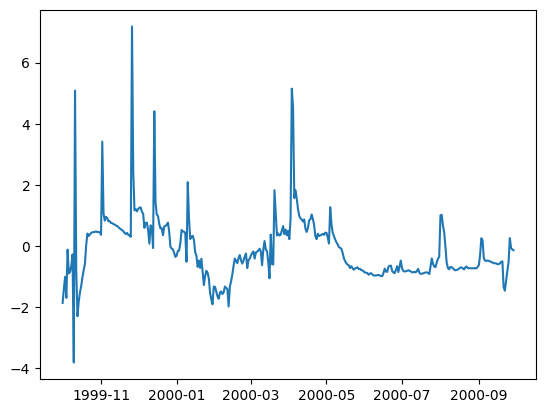

In [10]:
plt.plot(qsim_dynamic['datetime'], qsim_dynamic[0] - qsim_oracle[0],label='dynamic parameters')
plt.show()